In [1]:
import torch
import pickle
import librosa
import numpy as np
import soundfile as sf
import plotly.express as px
import IPython.display as ipd
import matplotlib.pyplot as plt

import librosa

from constants import *
from inferer import Inferer
from plotter import plot_waves
from disk_utils import load_model
from dataset import build_data_loaders

In [7]:
def plot_spec(f_path, t_path, title):
    signal, _ = librosa.load(f_path, mono=True, sr=SR)
    signal /= np.max(np.abs(signal))
    window = signal[0:WINDOW_SAMPLE_LEN]
    stft = librosa.stft(window, n_fft=N_FFT, hop_length=HOP)
    magnitude = np.abs(stft)

    db = librosa.amplitude_to_db(magnitude, ref=np.max)
    fig, ax = plt.subplots()
    img = librosa.display.specshow(
        db, x_axis="time", y_axis="log", ax=ax, sr=SR, hop_length=HOP)
    ax.set(title=title)
    fig.colorbar(img, ax=ax, format="%+2.f dB")
    fig.set_size_inches(6, 4)
    plt.rcParams["font.serif"] = ["Times New Roman"]
    plt.tight_layout()
    fig.savefig(t_path)
    plt.show()

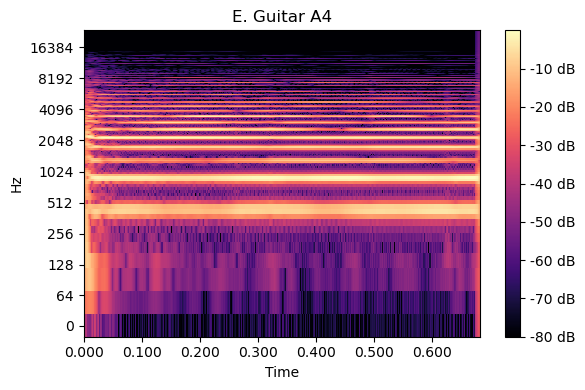

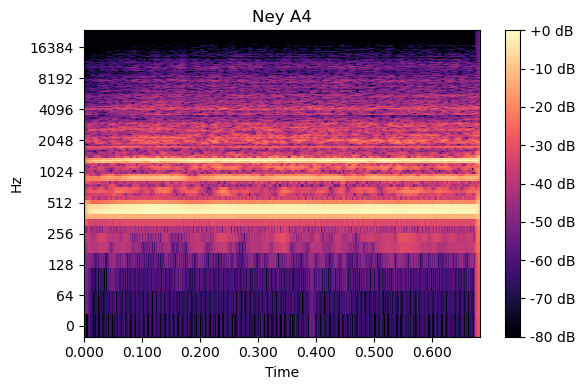

In [31]:
plot_spec("dataset/gtr_1/Gtr_1_15.wav", "figs/gtr_a4_spec.pdf", "E. Guitar A4")
plot_spec("dataset/ney_1/Ney_1_15.wav", "figs/ney_a4_spec.pdf", "Ney A4")

In [12]:
with open("dataset/features/min_max.pkl", "rb") as handle:
    min_max = pickle.load(handle)

inst = "ney"
feature = "db"
mini = min_max[inst]["min"][feature]
maxi = min_max[inst]["max"][feature]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model("generator_sp_32_0_8_full").to(device)

In [26]:
inferer = Inferer(device, mini, maxi, WINDOW_SAMPLE_LEN, OVERLAP, N_FFT, HOP)
signal, _ = librosa.load("dataset/gtr_1/Gtr_1_15.wav",
                         mono=True, sr=SR)
signal = signal[0:WINDOW_SAMPLE_LEN]
result_mag = inferer.infer(model, signal, use_gl=False, verbose=True)

Getting magnitude predictions...
  magnitude 1/1
Inverting predictions...
Stitching predictions...


In [29]:
result_mag /= np.max(np.abs(result_mag))
ipd.Audio(result_mag, rate=SR)
sf.write("figs/inf_a4.wav", result_mag, SR, format="wav")

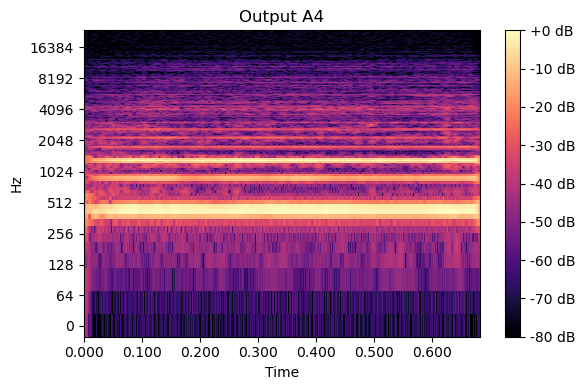

In [32]:
plot_spec("figs/inf_a4.wav", "figs/model_a4_spec.pdf", "Output A4")